In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as patches
import src.get_data_4 as gd
from scipy.ndimage import gaussian_filter

2026-02-13 16:34:34.757302: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771011274.770595   16200 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771011274.774869   16200 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771011274.785290   16200 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771011274.785305   16200 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771011274.785306   16200 computation_placer.cc:177] computation placer alr

In [2]:
# ---------------------------
# Arquitectura: U-Net compacto (DIP)
# ---------------------------

def make_generator_m(n, m, in_channels, out_channels=1, base_filters=64):
    """
    Generador U-Net con skip connections.

    Parámetros
    ----------
    n, m        : dimensiones espaciales de la entrada (y de la salida)
    in_channels : número de canales de entrada = C_noise + 1 (ruido + B_n)
    out_channels: canales de salida (1 por defecto)
    base_filters: filtros en el primer bloque del encoder
    """
    inp = layers.Input(shape=(n, m, in_channels))

    # --- Encoder ---
    e1 = layers.Conv2D(base_filters, 3, padding="same")(inp)
    e1 = layers.LeakyReLU(0.2)(e1)
    e1 = layers.Conv2D(base_filters, 3, padding="same")(e1)
    e1 = layers.LeakyReLU(0.2)(e1)
    p1 = layers.AveragePooling2D(pool_size=(2, 2))(e1)

    e2 = layers.Conv2D(base_filters * 2, 3, padding="same")(p1)
    e2 = layers.LeakyReLU(0.2)(e2)
    e2 = layers.Conv2D(base_filters * 2, 3, padding="same")(e2)
    e2 = layers.LeakyReLU(0.2)(e2)
    p2 = layers.AveragePooling2D(pool_size=(2, 2))(e2)

    # --- Bottleneck ---
    b = layers.Conv2D(base_filters * 4, 3, padding="same")(p2)
    b = layers.LeakyReLU(0.2)(b)
    b = layers.Conv2D(base_filters * 4, 3, padding="same")(b)
    b = layers.LeakyReLU(0.2)(b)

    # --- Decoder con skip connections ---
    u1 = layers.UpSampling2D()(b)
    u1 = layers.Concatenate()([u1, e2])
    d1 = layers.Conv2D(base_filters * 2, 3, padding="same")(u1)
    d1 = layers.LeakyReLU(0.2)(d1)
    d1 = layers.Conv2D(base_filters * 2, 3, padding="same")(d1)
    d1 = layers.LeakyReLU(0.2)(d1)

    u2 = layers.UpSampling2D()(d1)
    u2 = layers.Concatenate()([u2, e1])
    d2 = layers.Conv2D(base_filters, 3, padding="same")(u2)
    d2 = layers.LeakyReLU(0.2)(d2)
    d2 = layers.Conv2D(base_filters, 3, padding="same")(d2)
    d2 = layers.LeakyReLU(0.2)(d2)

    out = layers.Conv2D(out_channels, 1, padding="same", activation="linear")(d2)

    return Model(inputs=inp, outputs=out)


# ---------------------------
# Pérdida de variación total
# ---------------------------

def total_variation_loss(x):
    """Variación total isotrópica. x: tensor (batch, H, W, 1)."""
    dh = tf.abs(x[:, 1:, :, :] - x[:, :-1, :, :])
    dw = tf.abs(x[:, :, 1:, :] - x[:, :, :-1, :])
    return tf.reduce_mean(dh) + tf.reduce_mean(dw)


In [3]:
def run_dip_residual(cheap, mc_known, mask,
                     noise_channels=16,
                     iters=5000,
                     lr=1e-3,
                     weight_zero=0.02,
                     weight_tv=1e-3,
                     print_every=200):
    """
    Reconstrucción DIP en espacio de residuo: la red aprende Delta_M = M - B.

    La reconstrucción final es: M_hat = clip(B + Delta_M_hat, 0, 1)

    Parámetros
    ----------
    cheap          : matriz barata B completa (n, m)
    mc_known       : valores MC conocidos en Omega, resto 0  (n, m)
    mask           : 1 en puntos conocidos Omega, 0 en el resto (n, m)
    noise_channels : canales de ruido aleatorio (C_noise)
    iters          : iteraciones máximas
    lr             : learning rate de Adam
    weight_zero    : peso del prior de residuo cero en Omega^c (débil)
    weight_tv      : peso de la variación total sobre Delta_M
    print_every    : frecuencia de impresión
    """
    n, m = cheap.shape
    cheap    = cheap.astype(np.float32)
    mc_known = mc_known.astype(np.float32)
    mask     = mask.astype(np.float32)

    # --- Residuo observado en Omega: Delta_M = M - B ---
    residual_known = (mc_known - cheap) * mask   # cero fuera de Omega

    # --- Normalización del residuo por su rango observado ---
    obs_vals = residual_known[mask == 1]
    s_res = np.max(np.abs(obs_vals)) if len(obs_vals) > 0 else 1.0
    if s_res == 0.0:
        s_res = 1.0
    residual_n = residual_known / s_res   # residuo normalizado (solo Omega importa)

    # --- B normalizado como canal de entrada (contexto espacial) ---
    s_B = np.max(np.abs(cheap))
    if s_B == 0.0:
        s_B = 1.0
    cheap_n   = cheap / s_B
    B_channel = cheap_n[np.newaxis, :, :, np.newaxis]   # (1, n, m, 1)

    # --- Ruido fijo z: (1, n, m, C_noise) ---
    z = np.random.normal(size=(1, n, m, noise_channels)).astype(np.float32)

    # --- Generador: entrada = [z, B_n], salida = Delta_M_n ---
    in_channels = noise_channels + 1
    gen = make_generator_m(n, m, in_channels=in_channels, base_filters=64)
    optimizer = optimizers.Adam(learning_rate=lr)

    # --- Constantes TF ---
    mask_tf     = tf.constant(mask[np.newaxis, :, :, np.newaxis],           dtype=tf.float32)
    mask_inv_tf = tf.constant((1.0 - mask)[np.newaxis, :, :, np.newaxis],   dtype=tf.float32)
    resid_tf    = tf.constant(residual_n[np.newaxis, :, :, np.newaxis],     dtype=tf.float32)
    n_omega     = float(mask.sum())
    n_omega_c   = float((1.0 - mask).sum())

    # --- Historial y early stopping ---
    history   = {"loss_total": [], "loss_mc": [], "loss_zero": [], "loss_tv": []}
    best_loss = np.inf
    best_res  = None          # mejor Delta_M_n predicho
    patience  = max(200, int(0.15 * iters))
    wait      = 0
    ema_alpha = 0.05
    ema_loss  = None

    for it in range(1, iters + 1):
        z_jitter  = z + 0.03 * np.random.normal(size=z.shape).astype(np.float32)
        inp_batch = np.concatenate([z_jitter, B_channel], axis=-1)  # (1,n,m,C+1)

        with tf.GradientTape() as tape:
            delta_pred = gen(inp_batch, training=True)   # (1, n, m, 1) — Delta_M_n

            # L_mc: ajuste a los residuos conocidos en Omega
            loss_mc   = tf.reduce_sum(
                            tf.square((delta_pred - resid_tf) * mask_tf)
                        ) / (n_omega + 1e-8)

            # L_zero: prior de residuo nulo fuera de Omega (débil)
            loss_zero = tf.reduce_sum(
                            tf.square(delta_pred * mask_inv_tf)
                        ) / (n_omega_c + 1e-8)

            # L_tv: suavidad del residuo predicho
            loss_tv   = total_variation_loss(delta_pred)

            loss = loss_mc + weight_zero * loss_zero + weight_tv * loss_tv

        grads = tape.gradient(loss, gen.trainable_variables)
        optimizer.apply_gradients(zip(grads, gen.trainable_variables))

        lmc_val = float(loss_mc.numpy())
        history["loss_total"].append(float(loss.numpy()))
        history["loss_mc"].append(lmc_val)
        history["loss_zero"].append(float(loss_zero.numpy()))
        history["loss_tv"].append(float(loss_tv.numpy()))

        # EMA para early stopping
        ema_loss = lmc_val if ema_loss is None else ema_alpha * lmc_val + (1.0 - ema_alpha) * ema_loss

        if ema_loss < best_loss:
            best_loss = ema_loss
            best_res  = delta_pred.numpy()[0, :, :, 0].copy()
            wait = 0
        else:
            wait += 1

        if it % print_every == 0 or it == 1:
            print(f"it {it:05d} | loss={history['loss_total'][-1]:.4e} "
                  f"| mc={lmc_val:.4e}  zero={history['loss_zero'][-1]:.4e}  tv={history['loss_tv'][-1]:.4e}")

        if wait > patience:
            print(f"Early stopping en iteración {it} (sin mejora en loss_mc).")
            break

    # --- Reconstrucción final ---
    delta_final = best_res if best_res is not None else delta_pred.numpy()[0, :, :, 0]
    delta_final = delta_final * s_res          # des-normalizar residuo

    M_hat = cheap + delta_final                # B + Delta_M
    M_hat = np.clip(M_hat, 0.0, 1.0)          # SOC en [0,1]

    # Post-procesado: forzar valores exactos en puntos conocidos
    M_hat[mask == 1] = mc_known[mask == 1]

    return M_hat, delta_final, history


In [4]:
df = pd.read_csv("SOC_matrix_g-4.csv", header=None)  # usa la primera columna como índice
SOC_matrix = df.values

In [5]:
path = './datos_sqr-4/'
coord, soc, params = gd.get_points(path, max_degree=7)

In [7]:
len(soc)

25

In [ ]:
n, m = SOC_matrix.shape

known_points = coord
known_values = soc

# Construir máscara y mc_known
mask     = np.zeros((n, m), dtype=np.float32)
mc_known = np.zeros((n, m), dtype=np.float32)

for (i, j), val in zip(known_points, known_values):
    mask[i, j]     = 1.0
    mc_known[i, j] = val

cheap = SOC_matrix.copy().astype(np.float32)

# Ejecutar DIP en espacio de residuo
recon, delta, hist = run_dip_residual(
    cheap, mc_known, mask,
    noise_channels=16,
    iters=5000,
    lr=1e-3,
    weight_zero=0.02,
    weight_tv=1e-3,
)


it 00001 | loss=2.3946e-01 | mc=2.3887e-01  zero=2.0010e-02  tv=1.9140e-01


In [ ]:
# ---------------------------
# Diagnóstico: evolución de pérdidas
# ---------------------------

def plot_loss_history(history):
    """
    Grafica la evolución de cada componente de la pérdida y la EMA de loss_mc.
    """
    its = np.arange(1, len(history["loss_total"]) + 1)

    # Reconstruir EMA con el mismo alpha usado en entrenamiento
    ema_alpha = 0.05
    ema, val = [], None
    for v in history["loss_mc"]:
        val = v if val is None else ema_alpha * v + (1.0 - ema_alpha) * val
        ema.append(val)
    ema = np.array(ema)
    best_it = int(np.argmin(ema)) + 1

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Panel izquierdo: todas las pérdidas
    ax = axes[0]
    ax.semilogy(its, history["loss_total"], label="loss total",  alpha=0.7)
    ax.semilogy(its, history["loss_mc"],    label="loss MC (Ω)", alpha=0.7)
    ax.semilogy(its, history["loss_zero"],  label="loss zero",   alpha=0.7)
    ax.semilogy(its, history["loss_tv"],    label="loss TV",     alpha=0.7)
    ax.axvline(best_it, color="black", linestyle="--", lw=1.0, label=f"mejor it={best_it}")
    ax.set_xlabel("Iteración")
    ax.set_ylabel("Pérdida (escala log)")
    ax.set_title("Historial de pérdidas")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

    # Panel derecho: loss_mc cruda vs EMA
    ax = axes[1]
    ax.semilogy(its, history["loss_mc"], alpha=0.4, label="loss MC cruda")
    ax.semilogy(its, ema, linewidth=2,              label="EMA (α=0.05)")
    ax.axvline(best_it, color="black", linestyle="--", lw=1.0, label=f"mejor it={best_it}")
    ax.set_xlabel("Iteración")
    ax.set_ylabel("loss MC (escala log)")
    ax.set_title("Early stopping: loss MC vs EMA")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Iteraciones ejecutadas : {len(its)}")
    print(f"Mejor iteración (EMA)  : {best_it}")
    print(f"loss_mc en mejor it    : {history['loss_mc'][best_it-1]:.4e}")
    print(f"EMA en mejor it        : {ema[best_it-1]:.4e}")

plot_loss_history(hist)


NameError: name 'recon' is not defined

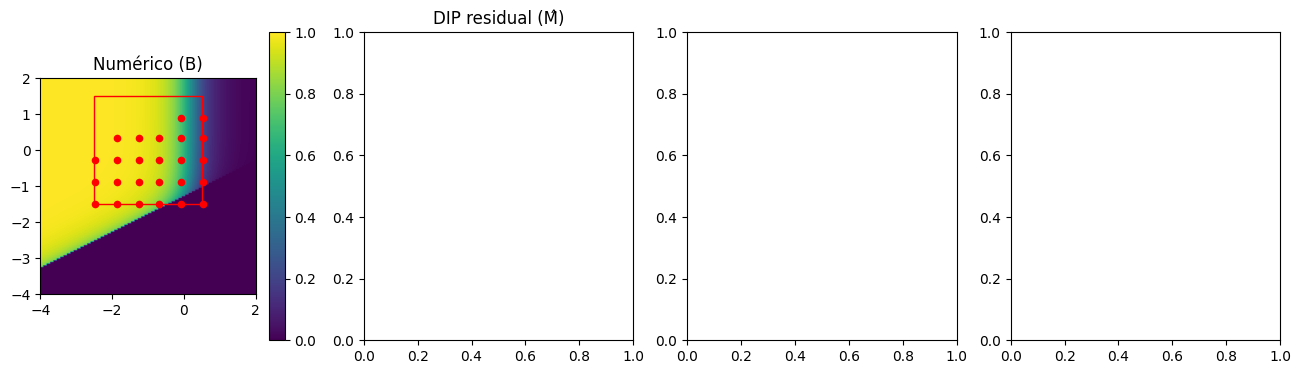

In [7]:
pts  = np.array(params)
extent = [-4, 2, -4, 2]
x0, y0, lado = -2.5, -1.5, 3

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

cheap = SOC_matrix

# Panel 1: matriz barata B
ax = axes[0]
ax.set_title("Numérico (B)")
im = ax.imshow(cheap.T, origin="lower", extent=extent, vmin=0, vmax=1)
ax.scatter(pts[:, 0], pts[:, 1], color="red", s=20)
ax.add_patch(patches.Rectangle((x0, y0), lado, lado,
             lw=1, edgecolor="red", facecolor="none"))
plt.colorbar(im, ax=ax)

# Panel 2: reconstrucción DIP M_hat = B + Delta
ax = axes[1]
ax.set_title("DIP residual (M̂)")
im = ax.imshow(recon.T, origin="lower", extent=extent, vmin=0, vmax=1)
ax.scatter(pts[:, 0], pts[:, 1], color="red", s=20)
plt.colorbar(im, ax=ax)

# Panel 3: residuo predicho Delta_M
ax = axes[2]
ax.set_title("Residuo predicho (ΔM̂)")
vmax_d = np.max(np.abs(delta))
im = ax.imshow(delta.T, origin="lower", extent=extent,
               cmap="RdBu_r", vmin=-vmax_d, vmax=vmax_d)
ax.scatter(pts[:, 0], pts[:, 1], color="black", s=20)
ax.add_patch(patches.Rectangle((x0, y0), lado, lado,
             lw=1, edgecolor="black", facecolor="none"))
plt.colorbar(im, ax=ax)

# Panel 4: diferencia M_hat - B
ax = axes[3]
ax.set_title("M̂ - B")
diff = recon - cheap
vmax_diff = np.max(np.abs(diff))
im = ax.imshow(diff.T, origin="lower", extent=extent,
                vmin=-vmax_diff, vmax=vmax_diff)
ax.scatter(pts[:, 0], pts[:, 1], color="black", s=20)
ax.add_patch(patches.Rectangle((x0, y0), lado, lado,
             lw=1, edgecolor="black", facecolor="none"))
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Diagnóstico numérico en los puntos conocidos
print("Verificación en puntos MC conocidos:")
print(f"  {'coord':>10}  {'M':>8}  {'M_hat':>8}  {'error':>8}")
print("  " + "-"*40)
for (i, j), val in zip(known_points, known_values):
    print(f"  ({i:3d},{j:3d})   {val:8.4f}  {recon[i,j]:8.4f}  {recon[i,j]-val:+8.4f}")
